In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=128,
    shuffle=False
)

100%|██████████| 170M/170M [00:03<00:00, 47.1MB/s]


In [ ]:
class SparseAutoencoder(nn.Module):

    def __init__(self, input_size=3072, hidden_size=512):
        super(SparseAutoencoder, self).__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(input_size, 1024),
            nn.ReLU(),
            nn.Linear(1024, hidden_size),
            nn.ReLU()
        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(hidden_size, 1024),
            nn.ReLU(),
            nn.Linear(1024, input_size),
            nn.Sigmoid()
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return encoded, decoded

In [ ]:
def sparsity_penalty(rho, rho_hat):

    rho_hat = torch.mean(torch.sigmoid(rho_hat), dim=0)

    rho = torch.tensor([rho] * len(rho_hat)).to(rho_hat.device)

    kl = rho * torch.log(rho / rho_hat) + (1 - rho) * torch.log((1 - rho) / (1 - rho_hat))

    return torch.sum(kl)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = SparseAutoencoder().to(device)

criterion = nn.MSELoss()

optimizer = optim.Adam(model.parameters(), lr=0.001)

rho = 0.05
beta = 1e-3

In [ ]:
num_epochs = 10

for epoch in range(num_epochs):

    total_loss = 0

    for images, _ in train_loader:

        images = images.view(images.size(0), -1).to(device)

        encoded, outputs = model(images)

        recon_loss = criterion(outputs, images)

        sparse_loss = sparsity_penalty(rho, encoded)

        loss = recon_loss + beta * sparse_loss

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {total_loss:.4f}")

Epoch [1/10], Loss: 183.5591
Epoch [2/10], Loss: 174.5850
Epoch [3/10], Loss: 173.0735
Epoch [4/10], Loss: 172.5534
Epoch [5/10], Loss: 172.1809
Epoch [6/10], Loss: 171.8738
Epoch [7/10], Loss: 171.6319
Epoch [8/10], Loss: 171.4296
Epoch [9/10], Loss: 171.2755
Epoch [10/10], Loss: 171.1486


In [ ]:
model.eval()

test_loss = 0

with torch.no_grad():

    for images, _ in test_loader:

        images = images.view(images.size(0), -1).to(device)

        _, outputs = model(images)

        loss = criterion(outputs, images)

        test_loss += loss.item()

print("Test Reconstruction Loss:", test_loss)

Test Reconstruction Loss: 14.150509998202324


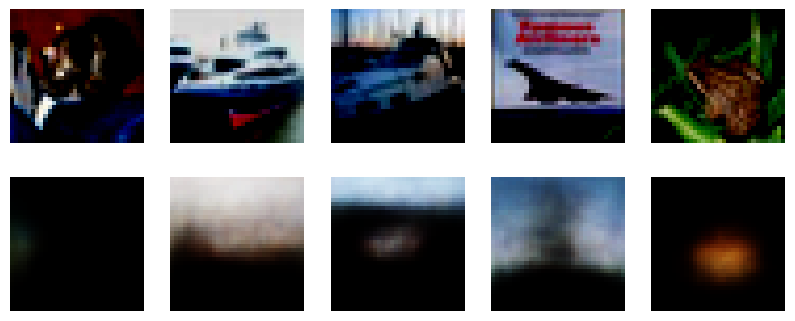

In [ ]:
dataiter = iter(test_loader)
images, _ = next(dataiter)

images = images.view(images.size(0), -1).to(device)

_, outputs = model(images)

images = images.cpu().view(-1,3,32,32)
outputs = outputs.cpu().view(-1,3,32,32)

plt.figure(figsize=(10,4))

for i in range(5):

    # Original
    plt.subplot(2,5,i+1)
    plt.imshow(np.transpose(images[i], (1,2,0)))
    plt.axis("off")

    # Reconstructed
    plt.subplot(2,5,i+6)
    plt.imshow(np.transpose(outputs[i].detach(), (1,2,0)))
    plt.axis("off")

plt.show()